# Laboratorio 5. Agentes en el Arcade Learning Environment (ALE): Space Invaders

CC3092 Deep Learning y Sistemas Inteligentes. Brandon Werner Rivera Cabrera 23088

El módulo de funciones también está en `ale_utils.py` para reutilizarlo en el Proyecto 2.

In [1]:
import os, time, warnings
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")   # evita que pygame busque audio al renderizar CartPole
warnings.filterwarnings("ignore", message=".*Overwriting existing videos.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
from gymnasium.wrappers import RecordVideo, AtariPreprocessing, FrameStackObservation

gym.register_envs(ale_py)
print("gymnasium", gym.__version__, "| ale_py", ale_py.__version__)
os.makedirs("videos", exist_ok=True); os.makedirs("figs", exist_ok=True)

gymnasium 1.3.0 | ale_py 0.12.1


## 1. Exploración del entorno

Espacios de observación y acción de `ALE/SpaceInvaders-v5`, sus variantes (`obs_type`, `frameskip`, `repeat_action_probability`, `full_action_space`) y comparación con `CartPole-v1`.

In [2]:
def describir(nombre, **kwargs):
    env = gym.make(nombre, **kwargs)
    print(f"{nombre} {kwargs if kwargs else ''}")
    print("   observación:", env.observation_space)
    print("   acción:     ", env.action_space)
    if hasattr(env.unwrapped, "get_action_meanings"):
        print("   acciones:   ", env.unwrapped.get_action_meanings())
    env.close()
    return env

env = describir("ALE/SpaceInvaders-v5")
print("   parámetros v5:", env.spec.kwargs)
describir("ALE/SpaceInvaders-v5", obs_type="ram")
describir("ALE/SpaceInvaders-v5", obs_type="grayscale")
describir("ALE/SpaceInvaders-v5", full_action_space=True)
_ = describir("CartPole-v1")

ALE/SpaceInvaders-v5 
   observación: Box(0, 255, (210, 160, 3), uint8)
   acción:      Discrete(6)
   acciones:    ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
   parámetros v5: {'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_frames_per_episode': 108000}


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


ALE/SpaceInvaders-v5 {'obs_type': 'ram'}
   observación: Box(0, 255, (128,), uint8)
   acción:      Discrete(6)
   acciones:    ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


ALE/SpaceInvaders-v5 {'obs_type': 'grayscale'}
   observación: Box(0, 255, (210, 160), uint8)
   acción:      Discrete(6)
   acciones:    ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


ALE/SpaceInvaders-v5 {'full_action_space': True}
   observación: Box(0, 255, (210, 160, 3), uint8)
   acción:      Discrete(18)
   acciones:    ['NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT', 'UPFIRE', 'RIGHTFIRE', 'LEFTFIRE', 'DOWNFIRE', 'UPRIGHTFIRE', 'UPLEFTFIRE', 'DOWNRIGHTFIRE', 'DOWNLEFTFIRE']
CartPole-v1 
   observación: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
   acción:      Discrete(2)


In [3]:
# Efecto del frame skipping en la velocidad de simulación (agente aleatorio)
def medir(frameskip, n_pasos=3000, seed=0):
    env = gym.make("ALE/SpaceInvaders-v5", frameskip=frameskip)
    env.reset(seed=seed)
    t0 = time.time()
    for _ in range(n_pasos):
        _, _, term, trunc, info = env.step(env.action_space.sample())
        if term or trunc:
            env.reset()
    dt = time.time() - t0
    env.close()
    return dict(frameskip=frameskip, decisiones_por_segundo=n_pasos / dt, frames_de_juego_por_segundo=n_pasos * frameskip / dt)

tabla_skip = pd.DataFrame([medir(1), medir(4)]).round(0)
tabla_skip

,frameskip,decisiones_por_segundo,frames_de_juego_por_segundo
0,1,6533.0,6533.0
1,4,2164.0,8657.0


cruda: (210, 160, 3) uint8 | AtariPreprocessing: (84, 84) uint8 | + FrameStack: (4, 84, 84) uint8


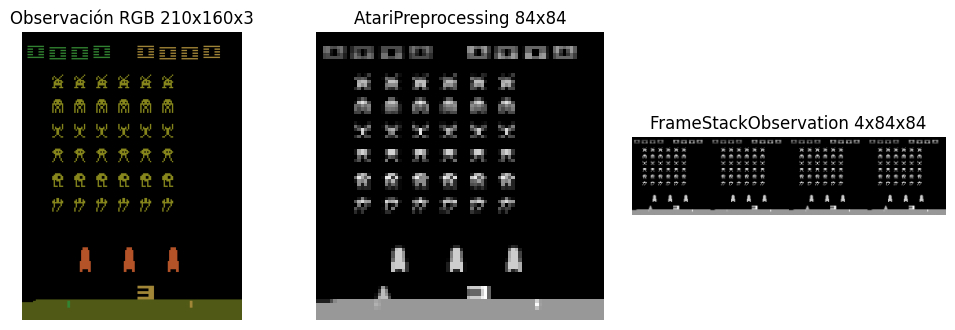

In [4]:
# Wrappers AtariPreprocessing y FrameStackObservation: forma de la observación en cada etapa
base = gym.make("ALE/SpaceInvaders-v5", frameskip=1)          # AtariPreprocessing exige frameskip=1 en el entorno base
pre = AtariPreprocessing(base, noop_max=30, frame_skip=4, screen_size=84, grayscale_obs=True, scale_obs=False)
apilado = FrameStackObservation(pre, stack_size=4)
obs_raw, _ = gym.make("ALE/SpaceInvaders-v5").reset(seed=0)
obs_pre, _ = pre.reset(seed=0)
obs_stack, _ = apilado.reset(seed=0)
print("cruda:", obs_raw.shape, obs_raw.dtype, "| AtariPreprocessing:", obs_pre.shape, obs_pre.dtype, "| + FrameStack:", obs_stack.shape, obs_stack.dtype)
for _ in range(20):
    obs_stack, _, _, _, _ = apilado.step(1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(obs_raw); axes[0].set_title("Observación RGB 210x160x3")
axes[1].imshow(obs_pre, cmap="gray"); axes[1].set_title("AtariPreprocessing 84x84")
axes[2].imshow(np.hstack(list(obs_stack)), cmap="gray"); axes[2].set_title("FrameStackObservation 4x84x84")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.savefig("figs/preprocesamiento.png", dpi=150); plt.show()
apilado.close()

## 2. Módulo de funciones para interactuar con ALE

`crear_entorno`, `agente_aleatorio`, `agente_regla_simple`, `ejecutar_episodio` y `generar_video_agente`. Las funciones son independientes del juego: `crear_entorno` y `generar_video_agente` funcionan con cualquier entorno de Gymnasium.

In [5]:
from typing import Callable

def crear_entorno(
    nombre_entorno: str = "ALE/SpaceInvaders-v5",
    video_folder: str | None = None,
    episode_trigger: Callable[[int], bool] | None = None,
    name_prefix: str = "video",
    render_mode: str | None = None,
    fps: int | None = None,
    **kwargs,
) -> gym.Env:
    """Crea y retorna un entorno de Gymnasium.

    Si se especifica video_folder, el entorno se envuelve con gymnasium.wrappers.RecordVideo
    para grabar los episodios que indique episode_trigger (por defecto, todos).
    kwargs se pasan a gym.make, por ejemplo obs_type, frameskip, repeat_action_probability
    o full_action_space en los entornos de ALE.
    """
    if video_folder is not None:
        render_mode = "rgb_array"
    env = gym.make(nombre_entorno, render_mode=render_mode, **kwargs)
    if video_folder is not None:
        if episode_trigger is None:
            episode_trigger = lambda episodio: True
        env = RecordVideo(
            env,
            video_folder=video_folder,
            episode_trigger=episode_trigger,
            name_prefix=name_prefix,
            fps=fps,
            disable_logger=True,
        )
    return env


def agente_aleatorio(observation, env: gym.Env) -> int:
    """Agente de referencia: acción uniforme al azar del espacio de acciones."""
    return env.action_space.sample()


COLOR_JUGADOR = np.array([50, 132, 50], dtype=np.uint8)
COLOR_ALIEN = np.array([134, 134, 29], dtype=np.uint8)
ACCION_FIRE, ACCION_RIGHTFIRE, ACCION_LEFTFIRE = 1, 4, 5


def agente_regla_simple(observation, env: gym.Env, margen: int = 2) -> int:
    """Regla fija para ALE/SpaceInvaders-v5 con observación RGB.

    Localiza el cañón del jugador por su color en las filas 185 a 195 y los invasores por su
    color en las filas 20 a 150. Calcula el centro horizontal de la fila más baja de invasores,
    se desplaza hacia él disparando y, cuando está alineado, solo dispara.
    Si la observación no es una imagen RGB de Atari, devuelve una acción aleatoria.
    """
    obs = np.asarray(observation)
    if obs.ndim != 3 or obs.shape[0] < 195 or obs.shape[2] != 3:
        return env.action_space.sample()
    xs_jugador = np.nonzero(np.all(obs[185:195] == COLOR_JUGADOR, axis=-1))[1]
    ys_alien, xs_alien = np.nonzero(np.all(obs[20:150] == COLOR_ALIEN, axis=-1))
    if len(xs_jugador) == 0 or len(xs_alien) == 0:
        return ACCION_FIRE
    x_jugador = xs_jugador.mean()
    fila_baja = ys_alien >= ys_alien.max() - 8
    objetivo = xs_alien[fila_baja].mean()
    if x_jugador < objetivo - margen:
        return ACCION_RIGHTFIRE
    if x_jugador > objetivo + margen:
        return ACCION_LEFTFIRE
    return ACCION_FIRE


def ejecutar_episodio(env: gym.Env, funcion_agente: Callable, max_steps: int = 10000, seed: int | None = None) -> dict:
    """Ejecuta un episodio completo hasta terminated, truncated o max_steps.

    Retorna un diccionario con pasos, recompensa total, terminated y truncated.
    """
    observation, info = env.reset(seed=seed)
    if seed is not None:
        env.action_space.seed(seed)  # hace reproducible también al agente aleatorio
    pasos, recompensa = 0, 0.0
    terminated = truncated = False
    while not (terminated or truncated) and pasos < max_steps:
        accion = funcion_agente(observation, env)
        observation, reward, terminated, truncated, info = env.step(accion)
        recompensa += float(reward)
        pasos += 1
    return {"pasos": pasos, "recompensa": recompensa, "terminated": bool(terminated), "truncated": bool(truncated)}


def generar_video_agente(
    nombre_entorno: str,
    funcion_agente: Callable,
    video_folder: str,
    name_prefix: str,
    n_episodios: int = 1,
    max_steps: int = 10000,
    seed: int | None = None,
    **kwargs,
) -> tuple[list[str], list[dict]]:
    """Crea el entorno con grabación de video, ejecuta n_episodios y cierra el entorno.

    Retorna la lista de rutas de los videos generados y la lista de métricas de cada episodio.
    env.close() es indispensable: RecordVideo escribe el archivo al cerrar el episodio o el entorno.
    """
    env = crear_entorno(nombre_entorno, video_folder=video_folder, episode_trigger=lambda e: True,
                        name_prefix=name_prefix, **kwargs)
    metricas = []
    try:
        for i in range(n_episodios):
            m = ejecutar_episodio(env, funcion_agente, max_steps=max_steps, seed=None if seed is None else seed + i)
            m["episodio"] = i
            metricas.append(m)
    finally:
        env.close()
    rutas = [os.path.join(video_folder, f"{name_prefix}-episode-{i}.mp4") for i in range(n_episodios)]
    rutas = [r for r in rutas if os.path.exists(r)]
    return rutas, metricas

## 3. Videos y métricas

Cada llamada a `generar_video_agente` crea el entorno con `RecordVideo`, ejecuta los episodios, cierra el entorno para que el video se escriba a disco y devuelve las rutas y las métricas.

In [6]:
rutas_aleatorio, metricas_aleatorio = generar_video_agente(
    "ALE/SpaceInvaders-v5", agente_aleatorio, video_folder="videos", name_prefix="aleatorio", n_episodios=3, seed=0)
for ruta, m in zip(rutas_aleatorio, metricas_aleatorio):
    print(f"{ruta}: pasos sobrevividos = {m['pasos']}, recompensa total = {m['recompensa']:.0f}")

videos/aleatorio-episode-0.mp4: pasos sobrevividos = 298, recompensa total = 35
videos/aleatorio-episode-1.mp4: pasos sobrevividos = 493, recompensa total = 155
videos/aleatorio-episode-2.mp4: pasos sobrevividos = 522, recompensa total = 150


In [7]:
rutas_regla, metricas_regla = generar_video_agente(
    "ALE/SpaceInvaders-v5", agente_regla_simple, video_folder="videos", name_prefix="regla_simple", n_episodios=3, seed=0)
for ruta, m in zip(rutas_regla, metricas_regla):
    print(f"{ruta}: pasos sobrevividos = {m['pasos']}, recompensa total = {m['recompensa']:.0f}")

videos/regla_simple-episode-0.mp4: pasos sobrevividos = 1121, recompensa total = 330
videos/regla_simple-episode-1.mp4: pasos sobrevividos = 1121, recompensa total = 290
videos/regla_simple-episode-2.mp4: pasos sobrevividos = 1121, recompensa total = 290


In [8]:
# Las mismas funciones sirven para cualquier entorno de Gymnasium
rutas_cartpole, metricas_cartpole = generar_video_agente(
    "CartPole-v1", agente_aleatorio, video_folder="videos", name_prefix="cartpole_aleatorio", n_episodios=1, seed=0)
for ruta, m in zip(rutas_cartpole, metricas_cartpole):
    print(f"{ruta}: pasos = {m['pasos']}, recompensa total = {m['recompensa']:.0f}")

videos/cartpole_aleatorio-episode-0.mp4: pasos = 18, recompensa total = 18


In [9]:
resumen = pd.DataFrame(
    [dict(agente="aleatorio", video=os.path.basename(r), **m) for r, m in zip(rutas_aleatorio, metricas_aleatorio)] +
    [dict(agente="regla simple", video=os.path.basename(r), **m) for r, m in zip(rutas_regla, metricas_regla)] +
    [dict(agente="aleatorio (CartPole-v1)", video=os.path.basename(r), **m) for r, m in zip(rutas_cartpole, metricas_cartpole)]
)[["agente", "video", "episodio", "pasos", "recompensa", "terminated", "truncated"]]
resumen

,agente,video,episodio,pasos,recompensa,terminated,truncated
0,aleatorio,aleatorio-episode-0.mp4,0,298,35.0,True,False
1,aleatorio,aleatorio-episode-1.mp4,1,493,155.0,True,False
2,aleatorio,aleatorio-episode-2.mp4,2,522,150.0,True,False
3,regla simple,regla_simple-episode-0.mp4,0,1121,330.0,True,False
4,regla simple,regla_simple-episode-1.mp4,1,1121,290.0,True,False
5,regla simple,regla_simple-episode-2.mp4,2,1121,290.0,True,False
6,aleatorio (CartPole-v1),cartpole_aleatorio-episode-0.mp4,0,18,18.0,True,False


In [10]:
# Comparación sin grabar video: 10 episodios por agente en ALE/SpaceInvaders-v5
env = crear_entorno("ALE/SpaceInvaders-v5")
comparacion = []
for nombre, agente in [("aleatorio", agente_aleatorio), ("regla simple", agente_regla_simple)]:
    for i in range(10):
        m = ejecutar_episodio(env, agente, seed=100 + i)
        comparacion.append(dict(agente=nombre, episodio=i, pasos=m["pasos"], recompensa=m["recompensa"]))
env.close()
comparacion = pd.DataFrame(comparacion)
medias = comparacion.groupby("agente")[["pasos", "recompensa"]].agg(["mean", "std", "min", "max"]).round(1)
medias

pasos                   recompensa                   
                mean   std   min   max       mean   std   min    max
agente                                                              
aleatorio      445.8  93.4   317   651      115.0  52.5  30.0  225.0
regla simple  1121.0   0.0  1121  1121      233.0  98.8  90.0  355.0

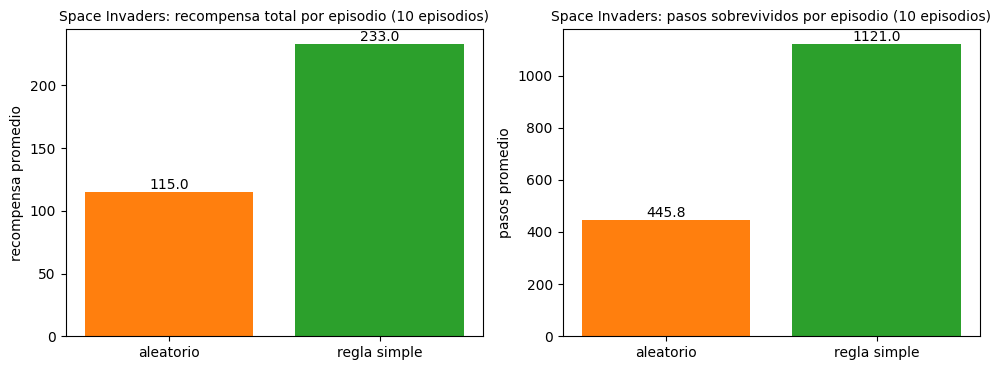

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
orden = ["aleatorio", "regla simple"]
colores = ["#ff7f0e", "#2ca02c"]
for ax, col, titulo in zip(axes, ["recompensa", "pasos"], ["Recompensa total por episodio", "Pasos sobrevividos por episodio"]):
    vals = [comparacion[comparacion.agente == a][col].mean() for a in orden]
    barras = ax.bar(orden, vals, color=colores)
    ax.bar_label(barras, fmt="%.1f")
    ax.set_title(f"Space Invaders: {titulo.lower()} (10 episodios)", fontsize=10)
    ax.set_ylabel(f"{col} promedio")
plt.tight_layout(); plt.savefig("figs/comparacion_agentes.png", dpi=150); plt.show()

In [12]:
from IPython.display import Video
Video(rutas_aleatorio[0], embed=False, width=320)